# Capstone - Plant Disease Detection End-to-End Pipeline

**Aim:** End-to-end data science pipeline for Plant Disease Detection.

## Theory

A complete machine learning workflow starts with data loading, followed by cleaning, feature engineering, exploratory analysis, visualization, modeling, and evaluation. Each stage matters because poor data quality affects features, weak features affect models, and incomplete evaluation can hide important errors. This capstone notebook ties those steps together into one reusable pipeline for PlantDoc-based disease detection analysis.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../logs/.mplconfig'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

TRAIN_DIR = Path('../data/PlantDoc-Dataset-master/train/')
TEST_DIR = Path('../data/PlantDoc-Dataset-master/test/')
MANIFEST_PATH = Path('../data/dataset_manifest.csv')
CLEAN_MANIFEST_PATH = Path('../data/dataset_manifest_clean.csv')
FEATURES_PATH = Path('../data/image_features.csv')

def scan_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    records = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['image_path', 'class_name', 'split'])
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file():
                records.append({
                    'image_path': str(image_path.as_posix()),
                    'class_name': class_dir.name,
                    'split': split_name,
                })
    return pd.DataFrame(records)


def ensure_manifest(prefer_clean: bool = True) -> pd.DataFrame:
    target = CLEAN_MANIFEST_PATH if prefer_clean and CLEAN_MANIFEST_PATH.exists() else MANIFEST_PATH
    if target.exists():
        return pd.read_csv(target)

    train_df = scan_split(TRAIN_DIR, 'train')
    test_df = scan_split(TEST_DIR, 'test')
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df['class_name'] = full_df['class_name'].astype(str).str.strip()
    full_df = full_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
    return full_df


def validate_image(image_path: str):
    path = Path(image_path)
    if not path.exists():
        return False, 'missing'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except Exception:
        return False, 'corrupt'


def load_rgb_image(image_path: str, size=(224, 224)):
    with Image.open(image_path) as img:
        rgb = img.convert('RGB').resize(size)
        return np.array(rgb)


def extract_rgb_features(image_array: np.ndarray) -> dict:
    channels = image_array.reshape(-1, 3)
    return {
        'mean_r': float(channels[:, 0].mean()),
        'mean_g': float(channels[:, 1].mean()),
        'mean_b': float(channels[:, 2].mean()),
        'std_r': float(channels[:, 0].std()),
        'std_g': float(channels[:, 1].std()),
        'std_b': float(channels[:, 2].std()),
    }


def ensure_features() -> pd.DataFrame:
    if FEATURES_PATH.exists():
        return pd.read_csv(FEATURES_PATH)

    manifest_df = ensure_manifest(prefer_clean=True).copy()
    quality_records = []
    for image_path in manifest_df['image_path']:
        valid, status = validate_image(image_path)
        quality_records.append((valid, status))
    manifest_df[['is_valid_image', 'file_status']] = pd.DataFrame(quality_records, index=manifest_df.index)
    manifest_df = manifest_df[manifest_df['is_valid_image']].copy().reset_index(drop=True)

    feature_rows = []
    for row in manifest_df.itertuples(index=False):
        image_array = load_rgb_image(row.image_path)
        feature_rows.append({
            'image_path': row.image_path,
            'class_name': row.class_name,
            'split': row.split,
            **extract_rgb_features(image_array),
        })

    features_df = pd.DataFrame(feature_rows)
    return features_df

from sklearn.ensemble import RandomForestClassifier

## Code

Loaded manifest shape: (2572, 3)


,image_count
class_name,
Corn leaf blight,191
Tomato Septoria leaf spot,151
Squash Powdery mildew leaf,130
Raspberry leaf,119
Corn rust leaf,116
Potato leaf early blight,116
Blueberry leaf,115
Peach leaf,111
Tomato leaf late blight,111


Imbalanced / very small classes:


,image_count
class_name,
Tomato two spotted spider mites leaf,2


Feature summary:


,mean_r,mean_g,mean_b,std_r,std_g,std_b
count,2572.000000,2572.000000,2572.000000,2572.000000,2572.000000,2572.000000
mean,122.912724,140.249818,97.713075,53.059747,50.811617,55.219492
std,43.311971,38.410172,45.461899,13.425415,13.236633,21.046527
min,21.657007,36.904476,2.965023,19.736224,16.795918,7.428977
25%,95.713489,116.764070,65.339585,43.561057,41.350166,40.471841
50%,113.181780,133.459891,87.875419,51.766279,50.193343,49.687360
75%,138.710489,155.433424,118.676598,61.551275,58.940702,64.881484
max,245.340422,244.696229,229.783721,108.388821,104.855193,124.999423


Top 5 classes:


,image_count
class_name,
Corn leaf blight,191
Tomato Septoria leaf spot,151
Squash Powdery mildew leaf,130
Raspberry leaf,119
Corn rust leaf,116


Bottom 5 classes:


,image_count
class_name,
Tomato leaf,63
Bell_pepper leaf,61
Cherry leaf,57
Tomato leaf mosaic virus,54
Tomato two spotted spider mites leaf,2


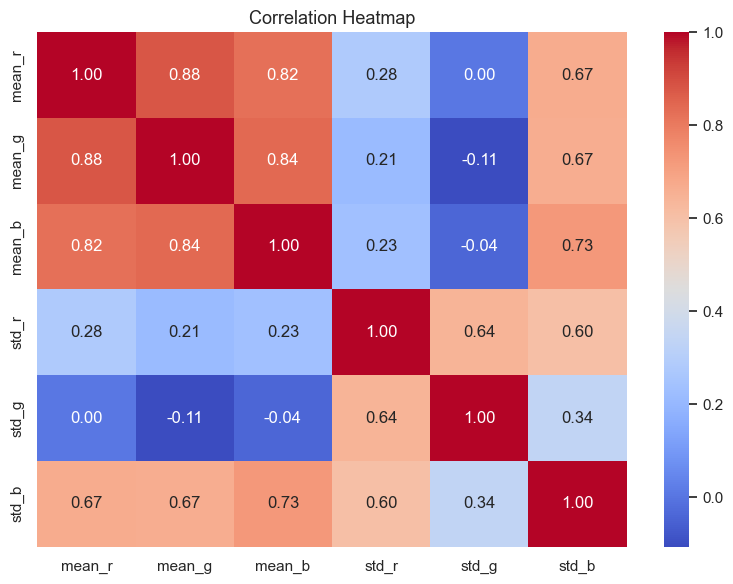

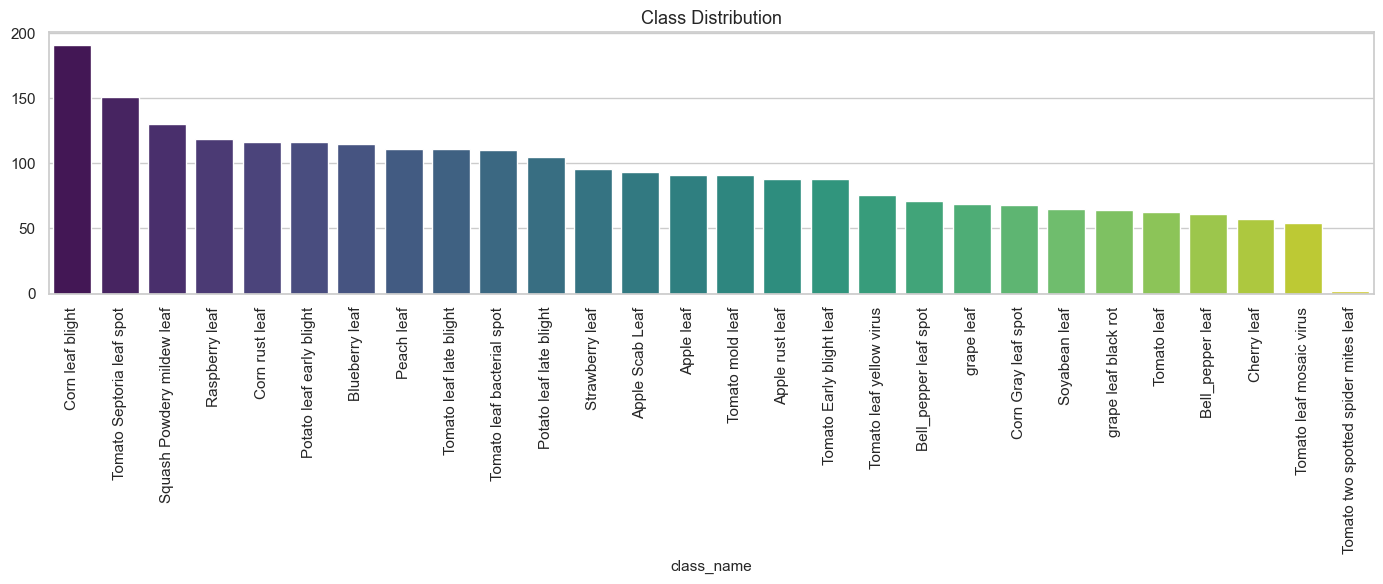

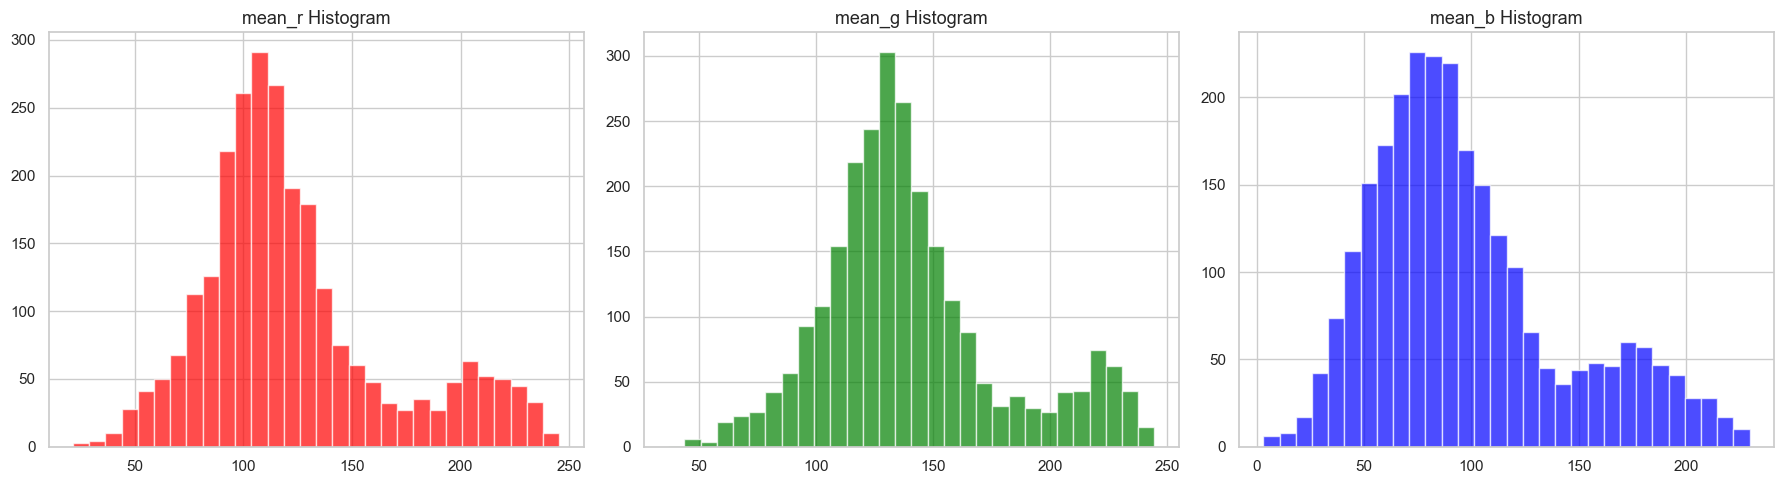

Accuracy: 0.17281553398058253
Macro F1: 0.1543198468729607

Classification report:
                            precision    recall  f1-score   support

           Apple Scab Leaf       0.07      0.05      0.06        19
                Apple leaf       0.36      0.22      0.28        18
           Apple rust leaf       0.06      0.06      0.06        18
          Bell_pepper leaf       0.00      0.00      0.00        12
     Bell_pepper leaf spot       0.27      0.21      0.24        14
            Blueberry leaf       0.50      0.30      0.38        23
               Cherry leaf       0.14      0.08      0.11        12
       Corn Gray leaf spot       0.12      0.07      0.09        14
          Corn leaf blight       0.22      0.39      0.29        38
            Corn rust leaf       0.05      0.04      0.05        23
                Peach leaf       0.50      0.50      0.50        22
  Potato leaf early blight       0.12      0.13      0.12        23
   Potato leaf late blight      

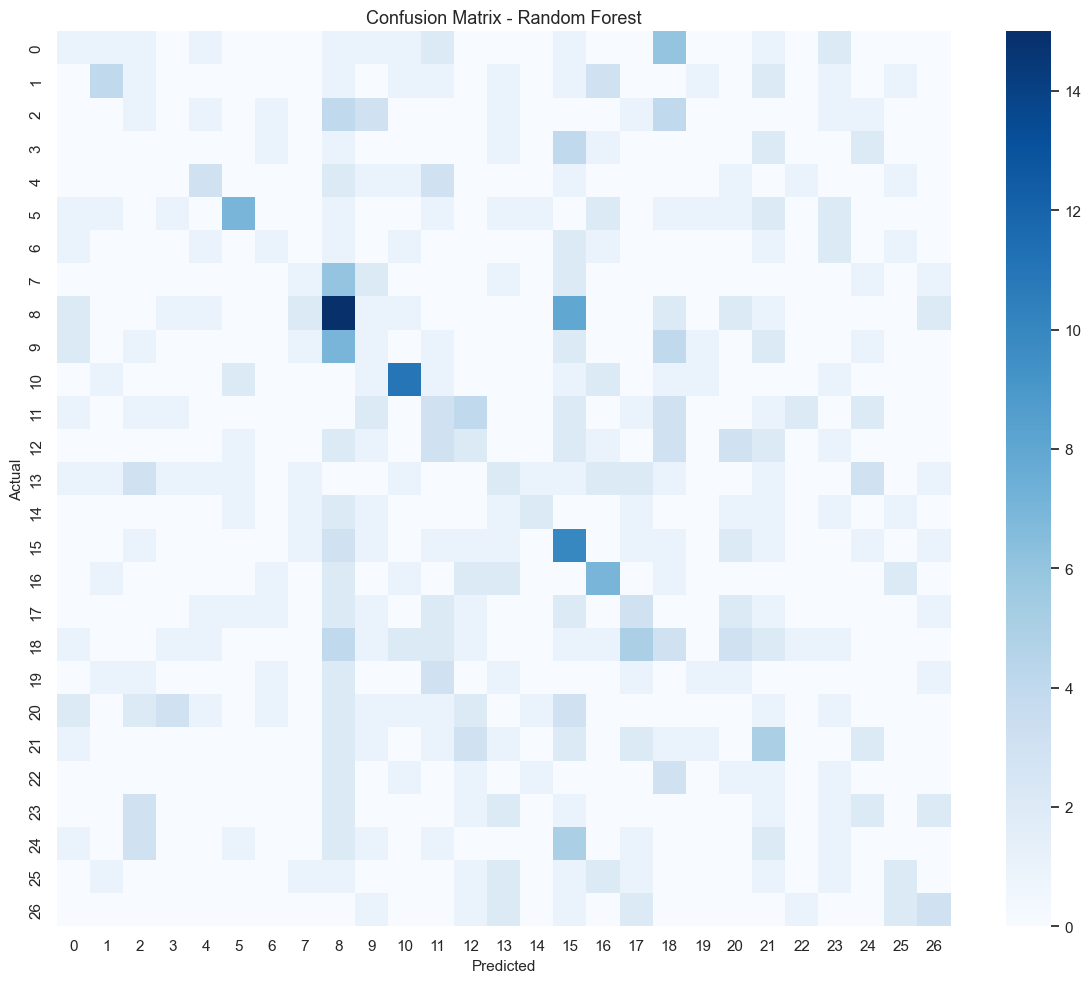

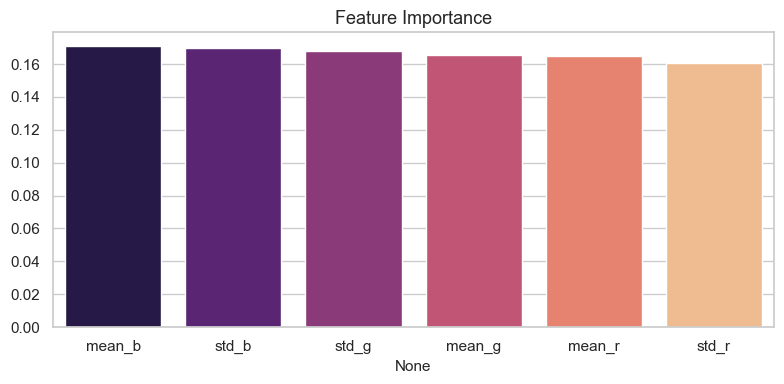

,metric,value
0,accuracy,0.172816
1,macro_f1,0.154320
2,n_classes,28.000000
3,n_samples,2572.000000


In [4]:
# SECTION 1 - Data Loading
manifest_df = ensure_manifest(prefer_clean=False).copy()
print('Loaded manifest shape:', manifest_df.shape)
display(manifest_df['class_name'].value_counts().to_frame(name='image_count'))

# SECTION 2 - Cleaning
manifest_df['file_exists'] = manifest_df['image_path'].apply(lambda p: Path(p).exists())
quality_checks = manifest_df['image_path'].apply(validate_image)
manifest_df['is_valid_image'] = quality_checks.apply(lambda x: x[0])
clean_df = manifest_df.drop_duplicates(subset=['image_path']).copy()
clean_df = clean_df[clean_df['file_exists'] & clean_df['is_valid_image']].reset_index(drop=True)
class_counts = clean_df['class_name'].value_counts()
imbalanced_classes = class_counts[class_counts <= 5]
print('Imbalanced / very small classes:')
display(imbalanced_classes.to_frame(name='image_count'))

# SECTION 3 - Feature Engineering
feature_rows = []
for row in clean_df.itertuples(index=False):
    image_array = load_rgb_image(row.image_path)
    feature_rows.append({
        'image_path': row.image_path,
        'class_name': row.class_name,
        'split': row.split,
        **extract_rgb_features(image_array),
    })
features_df = pd.DataFrame(feature_rows)
label_encoder = LabelEncoder()
features_df['label_encoded'] = label_encoder.fit_transform(features_df['class_name'])

# SECTION 4 - EDA
print('Feature summary:')
display(features_df[['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']].describe())
print('Top 5 classes:')
display(features_df['class_name'].value_counts().head(5).to_frame(name='image_count'))
print('Bottom 5 classes:')
display(features_df['class_name'].value_counts().tail(5).to_frame(name='image_count'))
plt.figure(figsize=(8, 6))
sns.heatmap(features_df[['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# SECTION 5 - Visualization
plt.figure(figsize=(14, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature, color in zip(axes, ['mean_r', 'mean_g', 'mean_b'], ['red', 'green', 'blue']):
    ax.hist(features_df[feature], bins=30, color=color, alpha=0.7)
    ax.set_title(f'{feature} Histogram')
plt.tight_layout()
plt.show()

# SECTION 6 - Modeling
feature_cols = ['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']
X = features_df[feature_cols]
y = features_df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# SECTION 7 - Evaluation
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print('Accuracy:', accuracy)
print('Macro F1:', macro_f1)
print('\nClassification report:')
# Get unique labels in test set and map to class names
unique_labels = np.unique(y_test)
target_names = label_encoder.inverse_transform(unique_labels)
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

feature_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=feature_importance.index, y=feature_importance.values, palette='magma')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# SECTION 8 - Summary Table
summary_df = pd.DataFrame({
    'metric': ['accuracy', 'macro_f1', 'n_classes', 'n_samples'],
    'value': [accuracy, macro_f1, features_df['class_name'].nunique(), len(features_df)]
})
display(summary_df)

## Results & Evaluation

In [5]:
print('Capstone metrics summary:')
display(summary_df)

Capstone metrics summary:


,metric,value
0,accuracy,0.172816
1,macro_f1,0.154320
2,n_classes,28.000000
3,n_samples,2572.000000


## Conclusion

This capstone notebook combines data preparation, RGB feature engineering, EDA, visualization, and baseline modeling into one end-to-end workflow. It shows what can be learned quickly from lightweight handcrafted features and also points to the next step: training a deeper image model such as EfficientNet for stronger disease recognition performance.